### Week6. Question 1  

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

### Q1a. 

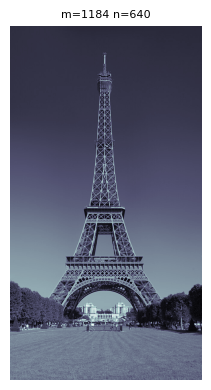

In [12]:
Mjpg=imageio.imread("GreyTourEiffel.jpg")        
M=Mjpg.astype(np.float64)                 
m,n=M.shape[:2]                          

plt.figure(figsize=(5,4))
plt.imshow(M,cmap="bone")
plt.title(f"m={m} n={n}", fontsize=8)
plt.axis("off")  

plt.tight_layout()

### Q1b. 

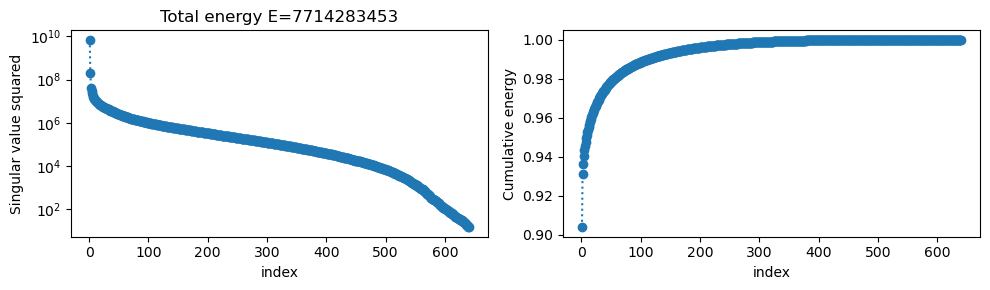

In [16]:
U,s,Vh=np.linalg.svd(M,full_matrices=False)   
Etot = np.sum(s**2)

plt.figure(figsize=(10, 3))

# Spectrum
plt.subplot(1,2,1)                        
plt.semilogy(np.arange(1, len(s)+1), s**2, ':o')
plt.title(f"Total energy E={int(round(Etot, 0))}")
plt.xlabel("index")
plt.ylabel("Singular value squared")

# Cumulative energy
plt.subplot(1, 2, 2)
cum_energy = np.cumsum(s**2) / Etot
plt.plot(np.arange(1, len(s)+1), cum_energy, ':o')
plt.xlabel("index")
plt.ylabel("Cumulative energy")

plt.tight_layout()

### Q1c. 

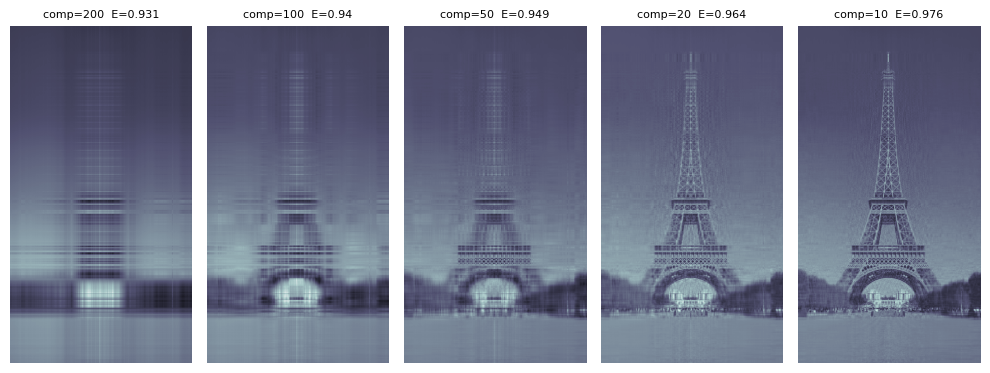

In [17]:
# Does the SVD up to k.
def MyMk(k: int) -> np.ndarray:
    return U[:, :k] @ np.diag(s[:k]) @ Vh[:k, :]

# Compression ratios
f = np.array([200, 100, 50, 20, 10])

plt.figure(figsize=(10, 4))

for i, fi in enumerate(f, start=1):
    
    k = int(round(m * n / (fi * (m + n + 1)), 0))
    approx = MyMk(k)

    # Energy fraction captured by the first k modes
    Efrac = round(np.sum(s[:k]**2) / Etot, 3)

    # Plot
    ax = plt.subplot(1, 5, i)
    ax.imshow(approx, cmap="bone")
    ax.set_title(f"comp={fi}  E={Efrac}", fontsize=8)
    ax.axis("off")

plt.tight_layout()